In [1]:
# Import libraries
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# nicer plots for notebooks
sns.set(style="whitegrid", rc={"figure.figsize":(10,6)})
%matplotlib inline

In [2]:
# Store API key and base URL
API_KEY = "fa2afb466f7b43f74136f01fd2cc7c9a"
BASE_URL = "https://api.stlouisfed.org/fred/series/observations"

In [3]:
# Helper function – fetch a series and return a tidy DataFrame
def fetch_series(series_id, observation_start="2000-01-01", observation_end=None):
    params = {
        "series_id": series_id,
        "api_key": API_KEY,
        "file_type": "json",
        "observation_start": observation_start,
    }
    if observation_end:
        params["observation_end"] = observation_end

    # Build the full request URL (visible to the user later)
    response = requests.get(BASE_URL, params=params)
    response.raise_for_status()  # will raise a helpful error if something went wrong

    data = response.json()["observations"]
    df = pd.DataFrame(data)
    df["date"] = pd.to_datetime(df["date"])
    # Convert the "value" column – some series use '.' for missing values
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df[["date", "value"]]

In [4]:
# FEDFUNDS (Federal Funds Rate)
fedfunds = fetch_series("FEDFUNDS")
fedfunds.head()

,date,value
0,2000-01-01,5.45
1,2000-02-01,5.73
2,2000-03-01,5.85
3,2000-04-01,6.02
4,2000-05-01,6.27


In [5]:
# CPIAUCSL (Consumer Price Index)
cpi = fetch_series("CPIAUCSL")
cpi.head()

,date,value
0,2000-01-01,169.3
1,2000-02-01,170.0
2,2000-03-01,171.0
3,2000-04-01,170.9
4,2000-05-01,171.2


In [6]:
# UNRATE (Unemployment Rate)
unrate = fetch_series("UNRATE")
unrate.head()

,date,value
0,2000-01-01,4.0
1,2000-02-01,4.1
2,2000-03-01,4.0
3,2000-04-01,3.8
4,2000-05-01,4.0


In [7]:
# M2SL (Money Supply M2)
m2 = fetch_series("M2SL")
m2.head()

,date,value
0,2000-01-01,4667.6
1,2000-02-01,4680.9
2,2000-03-01,4711.7
3,2000-04-01,4767.8
4,2000-05-01,4755.7


In [8]:
# INDPRO (Industrial Production Index)
indpro = fetch_series("INDPRO")
indpro.head()

,date,value
0,2000-01-01,91.5380
1,2000-02-01,91.8239
2,2000-03-01,92.1504
3,2000-04-01,92.6989
4,2000-05-01,92.9499


In [9]:
# UMCSENT (Consumer Sentiment)
umcsent = fetch_series("UMCSENT")
umcsent.head()

,date,value
0,2000-01-01,112.0
1,2000-02-01,111.3
2,2000-03-01,107.1
3,2000-04-01,109.2
4,2000-05-01,110.7


In [10]:
#GDPC1 (Real GDP)
gdpc1 = fetch_series("GDPC1")
gdpc1.head()

,date,value
0,2000-01-01,13878.147
1,2000-04-01,14130.908
2,2000-07-01,14145.312
3,2000-10-01,14229.765
4,2001-01-01,14183.120


In [11]:
# GS10 (10-Year Treasury Yield)
gs10 = fetch_series("GS10")
gs10.head()

,date,value
0,2000-01-01,6.66
1,2000-02-01,6.52
2,2000-03-01,6.26
3,2000-04-01,5.99
4,2000-05-01,6.44


In [12]:
# T10Y2Y (10-Year minus 2-Year Treasury Spread)
t10y2y = fetch_series("T10Y2Y")
t10y2y.head()

,date,value
0,2000-01-03,0.20
1,2000-01-04,0.19
2,2000-01-05,0.24
3,2000-01-06,0.22
4,2000-01-07,0.21


In [13]:
# USREC (NBER Recession Indicator)
usrec = fetch_series("USREC")
usrec.head()

,date,value
0,2000-01-01,0
1,2000-02-01,0
2,2000-03-01,0
3,2000-04-01,0
4,2000-05-01,0


In [14]:
# SP500 (S&P 500 Index)
sp500 = fetch_series("SP500")
sp500.head()

,date,value
0,2016-06-13,2079.06
1,2016-06-14,2075.32
2,2016-06-15,2071.50
3,2016-06-16,2077.99
4,2016-06-17,2071.22


In [15]:
# Rename the "value" columns to their series IDs
fedfunds.rename(columns={"value":"FEDFUNDS"}, inplace=True)
cpi.rename(columns={"value":"CPIAUCSL"}, inplace=True)
unrate.rename(columns={"value":"UNRATE"}, inplace=True)
m2.rename(columns={"value":"M2SL"}, inplace=True)
indpro.rename(columns={"value":"INDPRO"}, inplace=True)
umcsent.rename(columns={"value":"UMCSENT"}, inplace=True)
gdpc1.rename(columns={"value":"GDPC1"}, inplace=True)
gs10.rename(columns={"value":"GS10"}, inplace=True)
t10y2y.rename(columns={"value":"T10Y2Y"}, inplace=True)
usrec.rename(columns={"value":"USREC"}, inplace=True)
sp500.rename(columns={"value":"SP500"}, inplace=True)

In [16]:
# Merge all dataframes (outer join on date)
dfs = [fedfunds, cpi, unrate, m2, indpro, umcsent,
       gdpc1, gs10, t10y2y, usrec, sp500]

from functools import reduce
merged = reduce(lambda left, right: pd.merge(left, right, on="date", how="outer"), dfs)

# Sort by date for convenience
merged.sort_values("date", inplace=True)
merged.reset_index(drop=True, inplace=True)
merged.head()

,date,FEDFUNDS,CPIAUCSL,UNRATE,M2SL,INDPRO,UMCSENT,GDPC1,GS10,T10Y2Y,USREC,SP500
0,2000-01-01,5.45,169.3,4.0,4667.6,91.538,112.0,13878.147,6.66,NaN,0.0,NaN
1,2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.20,NaN,NaN
2,2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.19,NaN,NaN
3,2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.24,NaN,NaN
4,2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.22,NaN,NaN


In [17]:
# Check for missing values
missing_counts = merged.isna().sum()
missing_counts[missing_counts > 0]

FEDFUNDS    6674
CPIAUCSL    6675
UNRATE      6675
M2SL        6675
INDPRO      6675
UMCSENT     6675
GDPC1       6886
GS10        6674
T10Y2Y       377
USREC       6674
SP500       4478
dtype: int64

In [18]:
# Dataframe info (dtypes, memory usage)
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6991 entries, 0 to 6990
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      6991 non-null   datetime64[ns]
 1   FEDFUNDS  317 non-null    float64       
 2   CPIAUCSL  316 non-null    float64       
 3   UNRATE    316 non-null    float64       
 4   M2SL      316 non-null    float64       
 5   INDPRO    316 non-null    float64       
 6   UMCSENT   316 non-null    float64       
 7   GDPC1     105 non-null    float64       
 8   GS10      317 non-null    float64       
 9   T10Y2Y    6614 non-null   float64       
 10  USREC     317 non-null    float64       
 11  SP500     2513 non-null   float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 655.5 KB


In [19]:
# Summary statistics
merged.describe().T

,count,mean,min,25%,50%,75%,max,std
date,6991,2013-03-22 02:57:45.598626816,2000-01-01 00:00:00,2006-08-10 12:00:00,2013-03-22 00:00:00,2019-10-31 12:00:00,2026-06-11 00:00:00,NaN
FEDFUNDS,317.0,2.033502,0.05,0.15,1.3,3.94,6.54,2.025946
CPIAUCSL,316.0,234.709282,169.3,201.975,231.845,256.033,333.979,42.607828
UNRATE,316.0,5.623418,3.4,4.2,5.0,6.2,14.8,1.936161
M2SL,316.0,11922.076582,4667.6,6917.225,10555.65,15081.275,22804.5,5710.95357
INDPRO,316.0,97.29236,84.5619,92.98445,99.00645,101.022,104.1004,4.727638
UMCSENT,316.0,81.541456,49.8,70.8,82.7,93.0,112.0,14.178131
GDPC1,105.0,18328.61139,13878.147,16326.281,17662.4,20558.879,24152.656,2890.385672
GS10,317.0,3.337476,0.62,2.26,3.51,4.29,6.66,1.287459
T10Y2Y,6614.0,1.053335,-1.08,0.23,1.03,1.87,2.91,0.965453


In [20]:
# Save the merged dataset to CSV
output_path = "macroeconomic_dataset.csv"
merged.to_csv(output_path, index=False)
print(f"Saved dataset to {output_path}")

Saved dataset to macroeconomic_dataset.csv


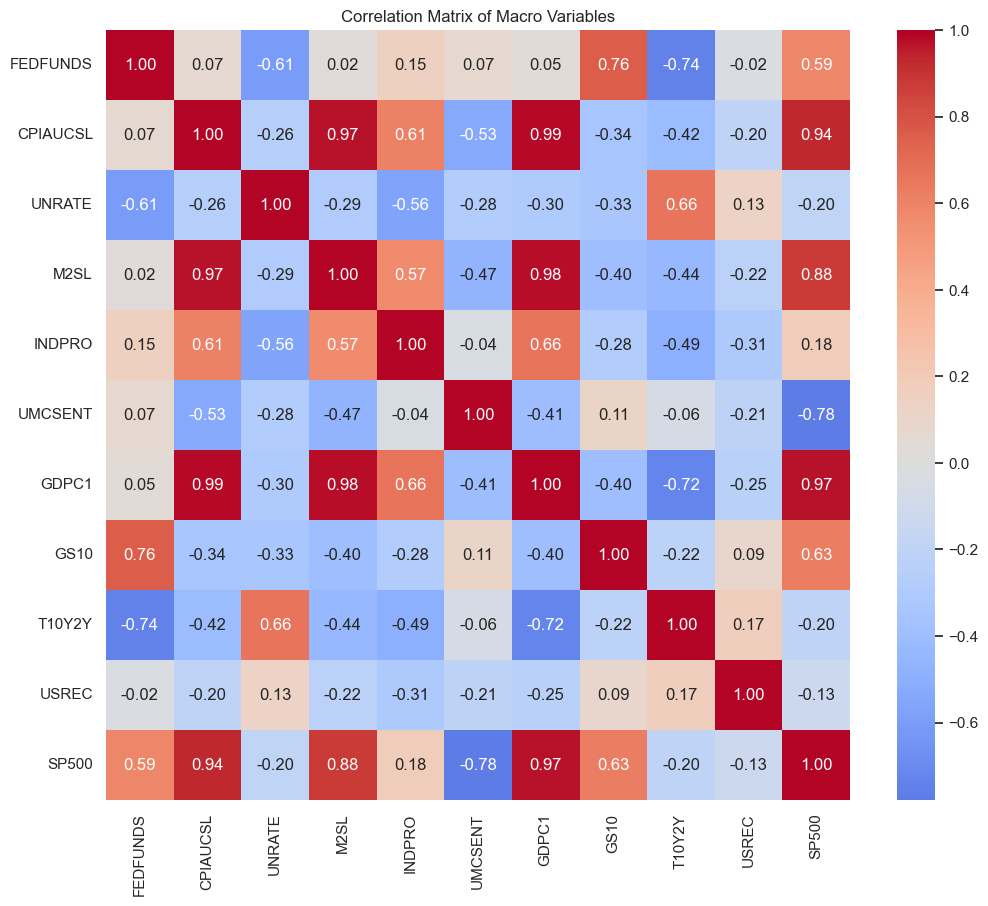

In [21]:
# Correlation matrix heatmap
corr = merged.select_dtypes(include='number').corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Macro Variables")
plt.show()

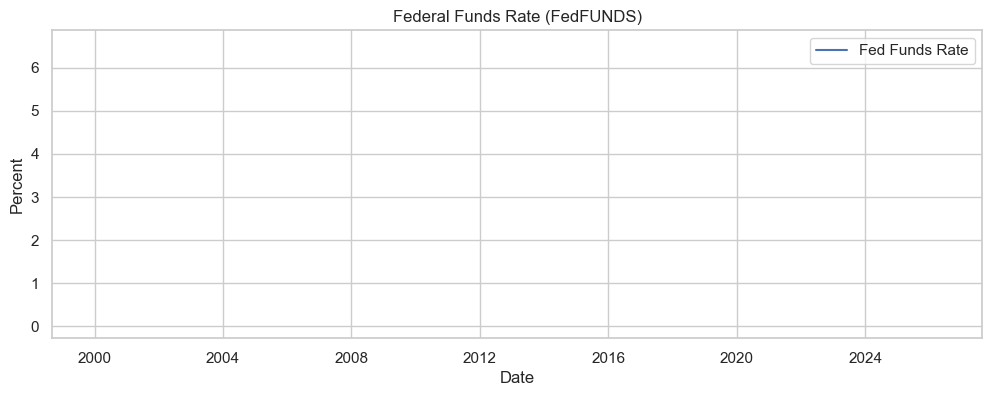

In [22]:
# Plot Federal Funds Rate over time
plt.figure(figsize=(12,4))
plt.plot(merged["date"], merged["FEDFUNDS"], label="Fed Funds Rate")
plt.title("Federal Funds Rate (FedFUNDS)")
plt.ylabel("Percent")
plt.xlabel("Date")
plt.legend()
plt.show()

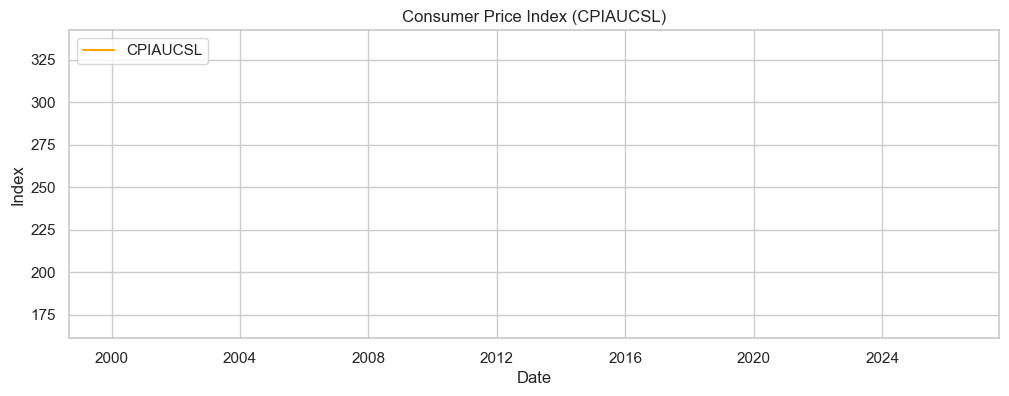

In [23]:
# Plot CPI (Consumer Price Index)
plt.figure(figsize=(12,4))
plt.plot(merged["date"], merged["CPIAUCSL"], label="CPIAUCSL", color="orange")
plt.title("Consumer Price Index (CPIAUCSL)")
plt.ylabel("Index")
plt.xlabel("Date")
plt.legend()
plt.show()

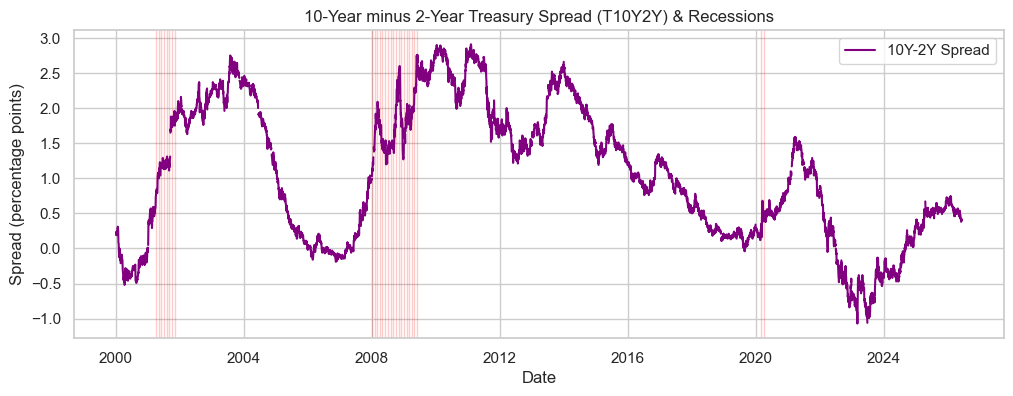

In [24]:
# Yield Curve Spread (T10Y2Y) with recession shading
plt.figure(figsize=(12,4))
plt.plot(merged["date"], merged["T10Y2Y"], label="10Y-2Y Spread", color="purple")

# Shade recession periods where USREC == 1
recession = merged[merged["USREC"] == 1]
for _, row in recession.iterrows():
    plt.axvspan(row["date"], row["date"], color="red", alpha=0.2)

plt.title("10-Year minus 2-Year Treasury Spread (T10Y2Y) & Recessions")
plt.xlabel("Date")
plt.ylabel("Spread (percentage points)")
plt.legend()
plt.show()

In [25]:
# Print all API URLs used (for transparency)
import urllib.parse

def build_url(series_id, start="2000-01-01", end=None):
    params = {
        "series_id": series_id,
        "api_key": API_KEY,
        "file_type": "json",
        "observation_start": start,
    }
    if end:
        params["observation_end"] = end
    return f"{BASE_URL}?{urllib.parse.urlencode(params)}"

series_ids = ["FEDFUNDS", "CPIAUCSL", "UNRATE", "M2SL", "INDPRO",
               "UMCSENT", "GDPC1", "GS10", "T10Y2Y", "USREC", "SP500"]

for sid in series_ids:
    print(build_url(sid))

https://api.stlouisfed.org/fred/series/observations?series_id=FEDFUNDS&api_key=fa2afb466f7b43f74136f01fd2cc7c9a&file_type=json&observation_start=2000-01-01
https://api.stlouisfed.org/fred/series/observations?series_id=CPIAUCSL&api_key=fa2afb466f7b43f74136f01fd2cc7c9a&file_type=json&observation_start=2000-01-01
https://api.stlouisfed.org/fred/series/observations?series_id=UNRATE&api_key=fa2afb466f7b43f74136f01fd2cc7c9a&file_type=json&observation_start=2000-01-01
https://api.stlouisfed.org/fred/series/observations?series_id=M2SL&api_key=fa2afb466f7b43f74136f01fd2cc7c9a&file_type=json&observation_start=2000-01-01
https://api.stlouisfed.org/fred/series/observations?series_id=INDPRO&api_key=fa2afb466f7b43f74136f01fd2cc7c9a&file_type=json&observation_start=2000-01-01
https://api.stlouisfed.org/fred/series/observations?series_id=UMCSENT&api_key=fa2afb466f7b43f74136f01fd2cc7c9a&file_type=json&observation_start=2000-01-01
https://api.stlouisfed.org/fred/series/observations?series_id=GDPC1&api_k